<a href="https://colab.research.google.com/github/prakashsurywanshi/quantum-safe-residential-iot/blob/main/A_Sustainable_Hybrid_QKD%E2%80%93PQC_Security_Architecture_for_Quantum_Resilient_Residential_IoT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== EXPERIMENTAL ENERGY CONSUMPTION (mJ) ===
 Scale (N)  Classical (mJ)  PQC-Only (mJ)  QKD-Assisted (mJ)  Hybrid QHSG (Proposed) (mJ)
        10           22.36          50.06             1.3856                      47.2744
        25           55.90         125.15             3.4640                     118.1860
        50          111.80         250.30             6.9280                     236.3720
       100          223.60         500.60            13.8560                     472.7440
       250          559.00        1251.50            34.6400                    1181.8600
       500         1118.00        2503.00            69.2800                    2363.7200


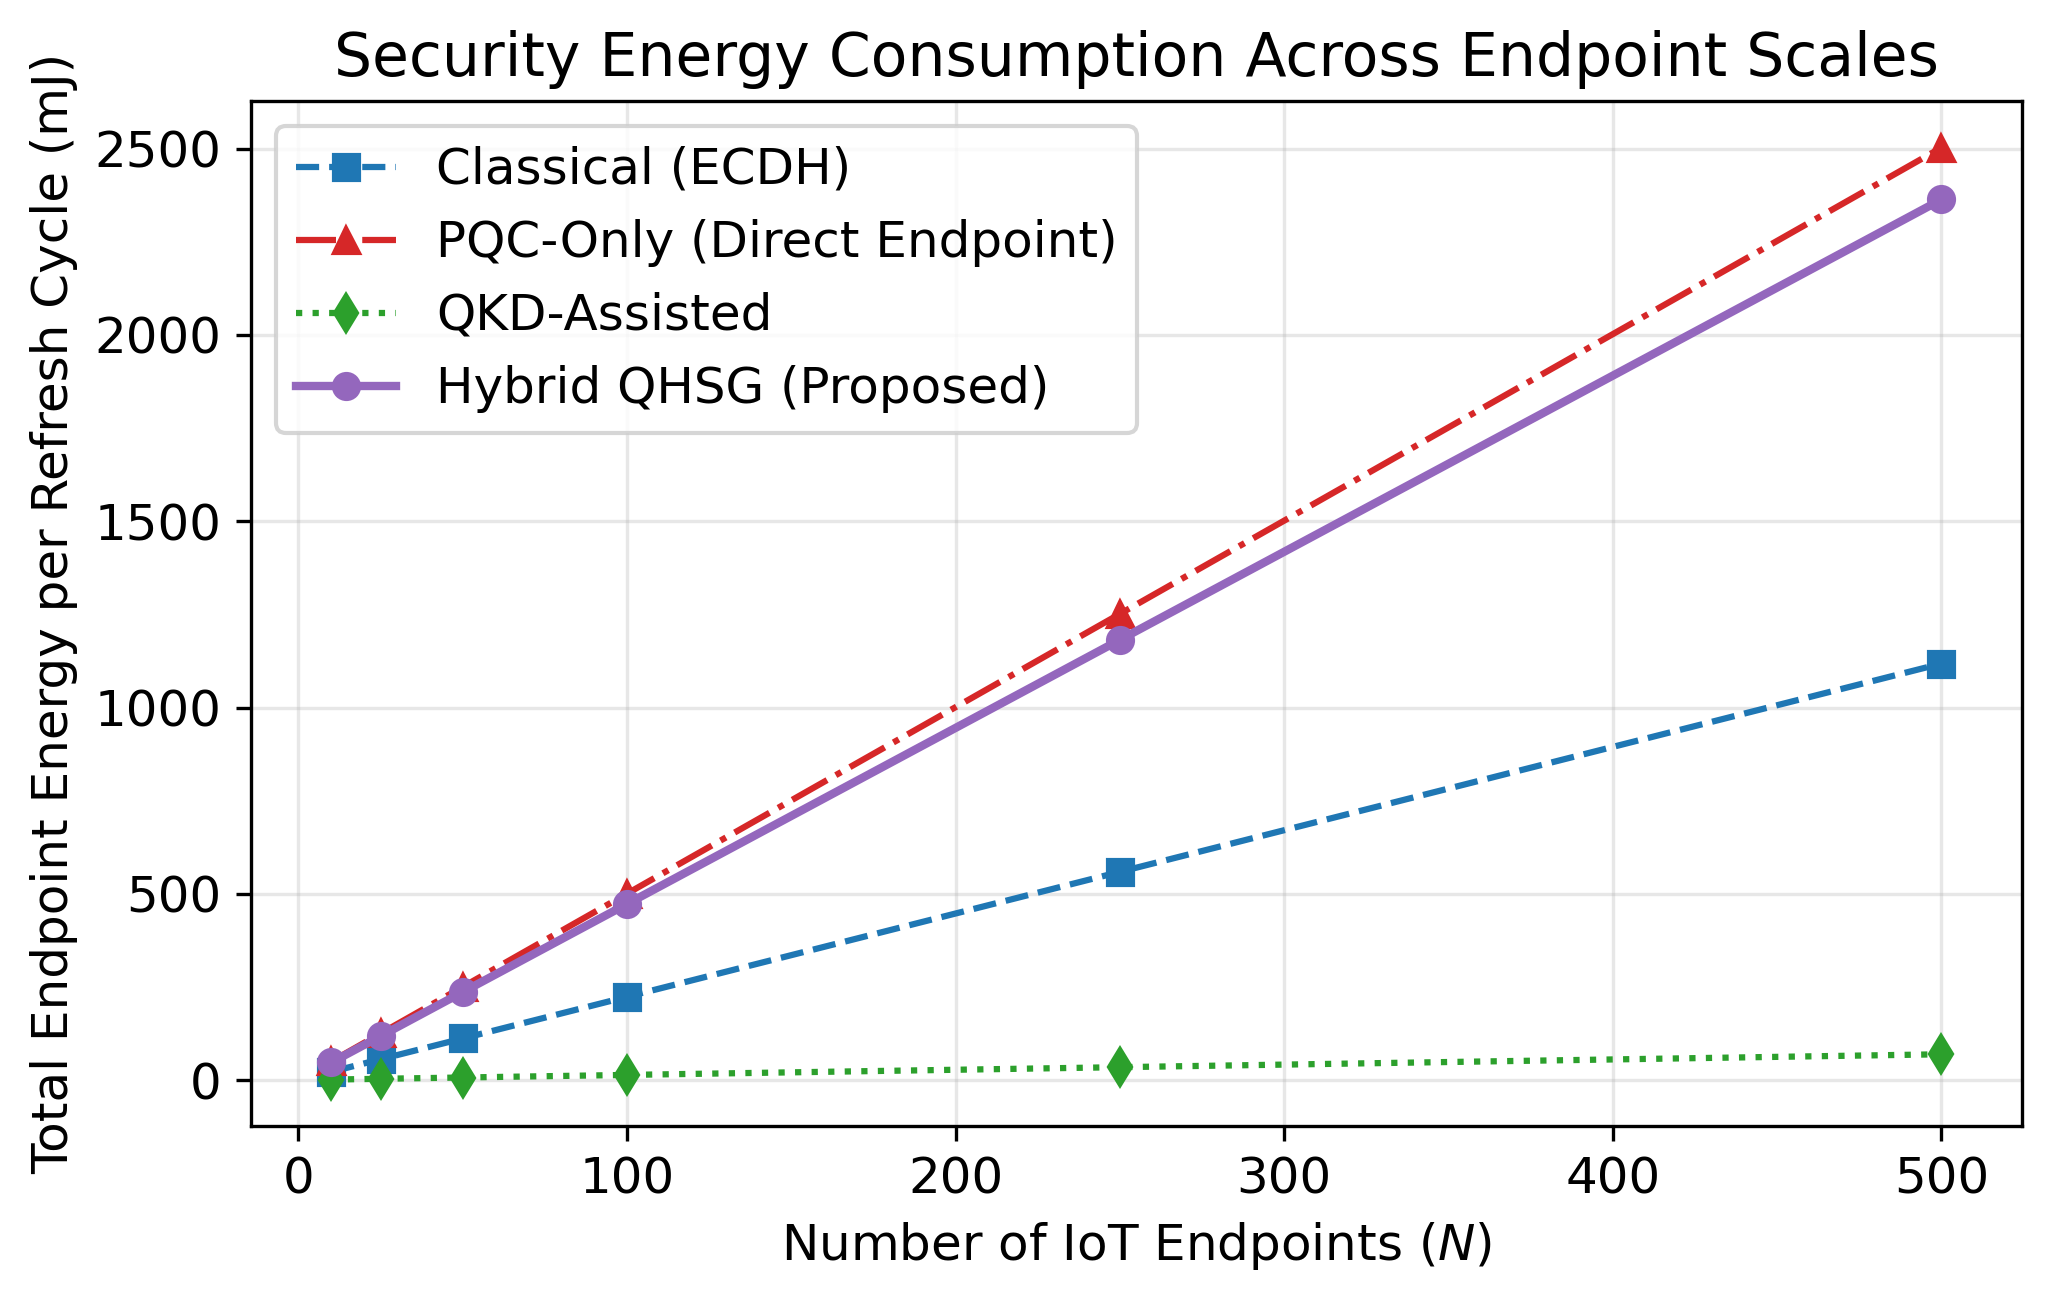

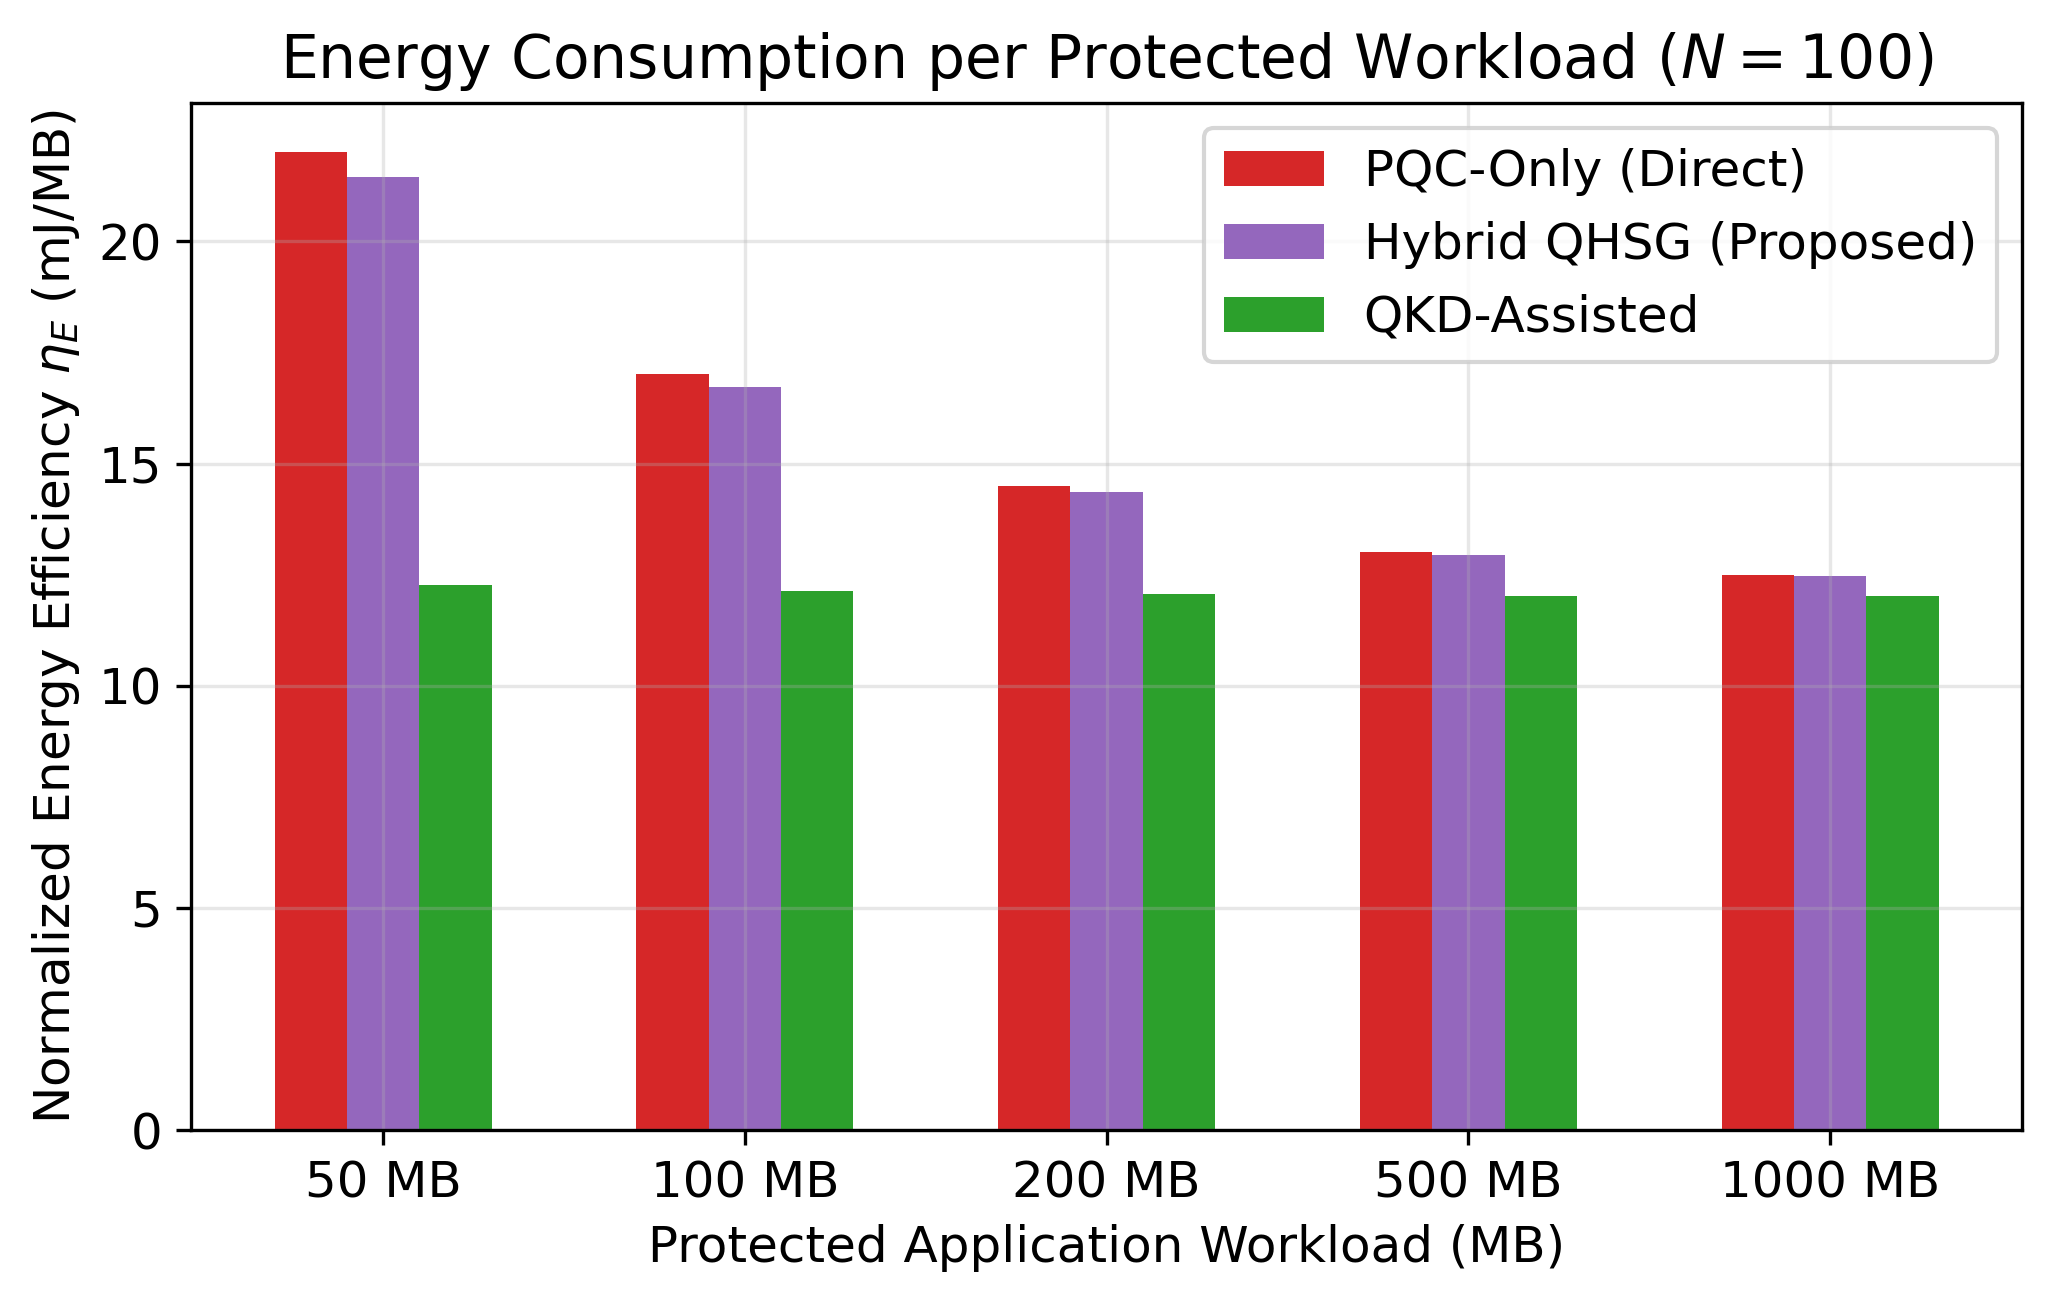

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set visual style suitable for Elsevier IEEE/SCI figures
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'figure.autolayout': True,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# ==========================================
# 1. PARAMETERS & BENCHMARK ASSUMPTIONS
# ==========================================
# Baseline energy and execution profile for ARM Cortex-M4 / ESP32 class devices:
# P_cpu ~ 132 mW (3.3V * 40mA), P_tx ~ 250 mW (Wi-Fi/BLE transmission)
P_CPU_W = 0.132
P_TX_W = 0.250

# Cryptographic execution time per handshake/key-gen (seconds)
T_EXEC = {
    'Classical (ECDH)': 0.015,       # 15 ms
    'PQC (ML-KEM-768)': 0.0035,     # 3.5 ms (lattice ops are computationally fast)
    'QKD-Assisted': 0.0008,          # Buffer read + nonce derivation
    'Hybrid (QHSG)': 0.0042          # HKDF combine (K_q || K_p)
}

# Key establishment communication payload (Bytes transmitted)
# Public keys, ciphertexts, signatures:
COMM_BYTES = {
    'Classical (ECDH)': 64 + 64,      # 128 B
    'PQC (ML-KEM-768)': 1184 + 1088,  # 2272 B (ML-KEM pubkey + ciphertext)
    'QKD-Assisted': 64,               # Key ID sync only
    'Hybrid (QHSG)': 2272 + 64        # PQC key exchange + QKD key-index
}

# Bitrate assumption: 1 Mbps for constrained IoT control channel
BITRATE = 1e6

def calc_energy_per_handshake(scheme, is_gateway_mediated=False):
    t_comp = T_EXEC[scheme]
    t_comm = (COMM_BYTES[scheme] * 8) / BITRATE

    # In QHSG architecture, endpoint only executes lightweight symmetric operations
    if is_gateway_mediated:
        # Endpoint energy reduced to simple symmetric payload encryption/decryption
        e_comp = (t_comp * 0.1) * P_CPU_W
        e_comm = t_comm * P_TX_W
    else:
        e_comp = t_comp * P_CPU_W
        e_comm = t_comm * P_TX_W

    return (e_comp + e_comm) * 1000  # Return in milliJoules (mJ)

# ==========================================
# 2. RUN SIMULATION ACROSS DEVICE SCALES (N)
# ==========================================
device_scales = [10, 25, 50, 100, 250, 500]

results = {
    'Scale (N)': device_scales,
    'Classical (mJ)': [],
    'PQC-Only (mJ)': [],
    'QKD-Assisted (mJ)': [],
    'Hybrid QHSG (Proposed) (mJ)': []
}

for n in device_scales:
    # Aggregated endpoint energy per session key refresh cycle across N devices
    e_classical = n * calc_energy_per_handshake('Classical (ECDH)', is_gateway_mediated=False)
    e_pqc = n * calc_energy_per_handshake('PQC (ML-KEM-768)', is_gateway_mediated=False)
    e_qkd = n * calc_energy_per_handshake('QKD-Assisted', is_gateway_mediated=True)
    e_hybrid = n * calc_energy_per_handshake('Hybrid (QHSG)', is_gateway_mediated=True)

    results['Classical (mJ)'].append(e_classical)
    results['PQC-Only (mJ)'].append(e_pqc)
    results['QKD-Assisted (mJ)'].append(e_qkd)
    results['Hybrid QHSG (Proposed) (mJ)'].append(e_hybrid)

df = pd.DataFrame(results)
print("=== EXPERIMENTAL ENERGY CONSUMPTION (mJ) ===")
print(df.to_string(index=False))

# ==========================================
# 3. GENERATE PUBLICATION-READY FIGURES
# ==========================================
# Figure 1: Energy vs Scalability
plt.figure(figsize=(7, 4.5), dpi=300)
plt.plot(df['Scale (N)'], df['Classical (mJ)'], 's--', label='Classical (ECDH)', color='#1f77b4', linewidth=1.5)
plt.plot(df['Scale (N)'], df['PQC-Only (mJ)'], '^-.', label='PQC-Only (Direct Endpoint)', color='#d62728', linewidth=1.5)
plt.plot(df['Scale (N)'], df['QKD-Assisted (mJ)'], 'd:', label='QKD-Assisted', color='#2ca02c', linewidth=1.5)
plt.plot(df['Scale (N)'], df['Hybrid QHSG (Proposed) (mJ)'], 'o-', label='Hybrid QHSG (Proposed)', color='#9467bd', linewidth=2)

plt.xlabel('Number of IoT Endpoints ($N$)')
plt.ylabel('Total Endpoint Energy per Refresh Cycle (mJ)')
plt.title('Security Energy Consumption Across Endpoint Scales')
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('Fig_Energy_Scalability.png', dpi=300)
plt.savefig('Fig_Energy_Scalability.pdf')
plt.show()

# Figure 2: Energy per Protected Data Unit (Joules / MB)
workload_mb = np.array([50, 100, 200, 500, 1000]) # MB transmitted
# Baseline symmetric streaming energy: ~ 0.012 mJ/KB -> 12 mJ/MB
base_stream_mj = workload_mb * 12.0

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)
bar_width = 0.2
x = np.arange(len(workload_mb))

eta_pqc = (base_stream_mj + results['PQC-Only (mJ)'][3]) / workload_mb
eta_hybrid = (base_stream_mj + results['Hybrid QHSG (Proposed) (mJ)'][3]) / workload_mb
eta_qkd = (base_stream_mj + results['QKD-Assisted (mJ)'][3]) / workload_mb

ax.bar(x - bar_width, eta_pqc, width=bar_width, label='PQC-Only (Direct)', color='#d62728')
ax.bar(x, eta_hybrid, width=bar_width, label='Hybrid QHSG (Proposed)', color='#9467bd')
ax.bar(x + bar_width, eta_qkd, width=bar_width, label='QKD-Assisted', color='#2ca02c')

ax.set_xlabel('Protected Application Workload (MB)')
ax.set_ylabel(r'Normalized Energy Efficiency $\eta_E$ (mJ/MB)')
ax.set_xticks(x)
ax.set_xticklabels([f'{w} MB' for w in workload_mb])
ax.legend(frameon=True)
plt.title(r'Energy Consumption per Protected Workload ($N=100$)')
plt.tight_layout()
plt.savefig('Fig_Energy_Per_MB.png', dpi=300)
plt.savefig('Fig_Energy_Per_MB.pdf')
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Try importing Google Colab file downloader (works automatically in Colab)
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ==========================================
# 0. PUBLICATION STYLE CONFIGURATION
# ==========================================
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.autolayout': True,
    'axes.grid': True,
    'grid.alpha': 0.3
})

output_dir = "paper_outputs"
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 1. PARAMETERS & BENCHMARKS
# ==========================================
P_CPU_W = 0.132      # ARM Cortex-M4 (3.3V * 40mA)
P_TX_W = 0.250       # Low-power transceiver (250 mW)
BITRATE = 1e6        # 1 Mbps control channel

T_EXEC = {
    'Classical (ECDH)': 0.015,
    'PQC (ML-KEM-768)': 0.0035,
    'QKD-Assisted': 0.0008,
    'Hybrid (QHSG)': 0.0042
}

COMM_BYTES = {
    'Classical (ECDH)': 128,
    'PQC (ML-KEM-768)': 2272,
    'QKD-Assisted': 64,
    'Hybrid (QHSG)': 2336
}

def calc_energy(scheme, is_gateway_mediated=False):
    t_comp = T_EXEC[scheme]
    t_comm = (COMM_BYTES[scheme] * 8) / BITRATE
    if is_gateway_mediated:
        e_comp = (t_comp * 0.1) * P_CPU_W
    else:
        e_comp = t_comp * P_CPU_W
    e_comm = t_comm * P_TX_W
    return (e_comp + e_comm) * 1000  # Return in mJ

# ==========================================
# 2. RUN EXPERIMENT ACROSS SCALES
# ==========================================
device_scales = [10, 25, 50, 100, 250, 500]

results = {
    'Scale_N': device_scales,
    'Classical_mJ': [n * calc_energy('Classical (ECDH)', False) for n in device_scales],
    'PQC_Only_mJ': [n * calc_energy('PQC (ML-KEM-768)', False) for n in device_scales],
    'QKD_Assisted_mJ': [n * calc_energy('QKD-Assisted', True) for n in device_scales],
    'Hybrid_QHSG_mJ': [n * calc_energy('Hybrid (QHSG)', True) for n in device_scales]
}

df_results = pd.DataFrame(results)

# Export Data Table to CSV
csv_path = os.path.join(output_dir, "Table_Energy_Results.csv")
df_results.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# ==========================================
# 3. FIGURE 1: SCALABILITY PLOT
# ==========================================
plt.figure(figsize=(6.5, 4.0), dpi=300)
plt.plot(df_results['Scale_N'], df_results['Classical_mJ'], 's--', label='Classical (ECDH)', color='#1f77b4', linewidth=1.5)
plt.plot(df_results['Scale_N'], df_results['PQC_Only_mJ'], '^-.', label='PQC-Only (ML-KEM-768)', color='#d62728', linewidth=1.5)
plt.plot(df_results['Scale_N'], df_results['QKD_Assisted_mJ'], 'd:', label='QKD-Assisted', color='#2ca02c', linewidth=1.5)
plt.plot(df_results['Scale_N'], df_results['Hybrid_QHSG_mJ'], 'o-', label='Hybrid QHSG (Proposed)', color='#9467bd', linewidth=1.8)

plt.xlabel('Number of IoT Endpoints ($N$)')
plt.ylabel('Endpoint Refresh Energy (mJ)')
plt.title('Endpoint Security Energy Overhead across Fleet Scales')
plt.legend(frameon=True)
plt.tight_layout()

# Save PNG and Vector PDF
f1_png = os.path.join(output_dir, "Fig_Energy_Scalability.png")
f1_pdf = os.path.join(output_dir, "Fig_Energy_Scalability.pdf")
plt.savefig(f1_png, dpi=300)
plt.savefig(f1_pdf)
plt.close()
print(f"Saved: {f1_png} and {f1_pdf}")

# ==========================================
# 4. FIGURE 2: WORKLOAD EFFICIENCY (BAR)
# ==========================================
workload_mb = np.array([50, 100, 200, 500, 1000])
base_stream_mj = workload_mb * 12.0  # 12 mJ/MB baseline symmetric streaming

n100_idx = device_scales.index(100)
eta_pqc = (base_stream_mj + results['PQC_Only_mJ'][n100_idx]) / workload_mb
eta_hybrid = (base_stream_mj + results['Hybrid_QHSG_mJ'][n100_idx]) / workload_mb
eta_qkd = (base_stream_mj + results['QKD_Assisted_mJ'][n100_idx]) / workload_mb

fig, ax = plt.subplots(figsize=(6.5, 4.0), dpi=300)
bar_width = 0.25
x = np.arange(len(workload_mb))

ax.bar(x - bar_width, eta_pqc, width=bar_width, label='PQC-Only (Direct)', color='#d62728')
ax.bar(x, eta_hybrid, width=bar_width, label='Hybrid QHSG (Proposed)', color='#9467bd')
ax.bar(x + bar_width, eta_qkd, width=bar_width, label='QKD-Assisted', color='#2ca02c')

ax.set_xlabel('Application Payload Volume (MB)')
ax.set_ylabel(r'Normalized Energy Efficiency $\eta_E$ (mJ/MB)')
ax.set_xticks(x)
ax.set_xticklabels([f'{w} MB' for w in workload_mb])
ax.legend(frameon=True)
plt.title(r'Workload-Normalized Energy Consumption ($N=100$)')
plt.tight_layout()

# Save PNG and Vector PDF
f2_png = os.path.join(output_dir, "Fig_Energy_Per_MB.png")
f2_pdf = os.path.join(output_dir, "Fig_Energy_Per_MB.pdf")
plt.savefig(f2_png, dpi=300)
plt.savefig(f2_pdf)
plt.close()
print(f"Saved: {f2_png} and {f2_pdf}")

# ==========================================
# 5. AUTOMATIC COLAB DOWNLOAD
# ==========================================
if IN_COLAB:
    print("\nInitiating downloads to your local machine...")
    files.download(f1_png)
    files.download(f1_pdf)
    files.download(f2_png)
    files.download(f2_pdf)
    files.download(csv_path)

Saved: paper_outputs/Table_Energy_Results.csv
Saved: paper_outputs/Fig_Energy_Scalability.png and paper_outputs/Fig_Energy_Scalability.pdf
Saved: paper_outputs/Fig_Energy_Per_MB.png and paper_outputs/Fig_Energy_Per_MB.pdf

Initiating downloads to your local machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>